## **Sample**

In [ ]:
import pandas as pd
import json

# ========== 1) Read dataset ==========
df = pd.read_csv("arabicaqa_rag_results/dataset/df_all_mrc.csv")

# ========== 2) Decode list-like columns stored as JSON strings ==========
list_columns = ["answers"]  

for col in list_columns:
    df[col] = df[col].apply(
        lambda x: json.loads(x) if isinstance(x, str) and x.strip().startswith("[") else []
    )

# ========== 3) Split dataset into answerable / unanswerable ==========
df_answerable = df[df["is_impossible"] == False]
df_unanswerable = df[df["is_impossible"] == True]

# ========== 4) Sample 500 from each ==========
sample_answerable = df_answerable.sample(500, random_state=42)
sample_unanswerable = df_unanswerable.sample(500, random_state=42)

# ========== 5) Combine into final sample ==========
df_sample = pd.concat([sample_answerable, sample_unanswerable], ignore_index=True)

print("Sample shape:", df_sample.shape)
df_sample.head()


Sample shape: (1000, 7)


,split,document_id,question_id,question,context,answers,is_impossible
0,train,1732461,1193607,متي تم بناء الموقع الأول لشركة توب غولف؟,توب غولف هي شركة ترفيهية رياضية عالمية مقرها ف...,[عام 2000],False
1,test,1583712,1160774,كم عدد الحفريات التي تم اكتشافها لببر نغاندونغ؟,ببر نغاندونغ هو نويع منقرض من أنواع الببور الح...,[سبع حفريات],False
2,train,1718678,1164879,ما هو مركز اللاعب ميو تساكتاش؟,ميو تساكتاش (8 مايو 1992 في سبليت في كرواتيا -...,[كصانع ألعاب],False
3,test,1582958,1068610,ما هي بعض المنتجات التي يمكن صنعها من القماش ا...,القماش الهَسِّيّ هو قماش منسوج يصنع عادة من أل...,[لصنع الحبال والشبكات والمنتجات المماثلة],False
4,test,1720179,1175188,ما هو مركز اللاعب رادو سابو؟,رادو سابو هو لاعب كرة قدم روماني في مركز الوسط...,[الوسط],False


In [ ]:
import pandas as pd
import json

# ======================================================
# 1) Load the sample
# ======================================================

df_sample = df_sample.copy() 


# ======================================================
# 2) Helper: safe parsing for list-columns (answers)
# ======================================================

def safe_parse_list(x):
    """Return a clean Python list, fixing formatting problems."""
    
    if isinstance(x, list):
        return x
    
    if pd.isna(x):
        return []
    
    s = str(x).strip()
    if s == "":
        return []

    # Try JSON as-is
    try:
        return json.loads(s)
    except:
        pass
    
    # Try JSON with single-quotes replaced
    try:
        s2 = s.replace("'", '"')
        return json.loads(s2)
    except:
        pass
    
    # Fallback: return as single-item list
    return [s]


# ======================================================
# 3) Fix list-columns (answers)
# ======================================================

list_columns = ["answers"]

for col in list_columns:
    df_sample[col] = df_sample[col].apply(safe_parse_list)


# ======================================================
# 4) Clean other text columns: strip whitespace, ensure strings
# ======================================================

text_columns = ["question", "context"]

for col in text_columns:
    df_sample[col] = df_sample[col].fillna("").astype(str).str.strip()


# ======================================================
# 5) Optional safety checks (remove broken rows)
# ======================================================

# Remove empty context/question rows (rare but safe)
df_sample = df_sample[df_sample["question"] != ""]
df_sample = df_sample[df_sample["context"] != ""]

# Ensure is_impossible is boolean
df_sample["is_impossible"] = df_sample["is_impossible"].astype(bool)


# ======================================================
# 6) Save cleaned sample
# ======================================================

output_path = "arabicaqa_rag_results/dataset/df_sample_1000.csv"

# Convert lists into JSON before saving
df_to_save = df_sample.copy()
for col in list_columns:
    df_to_save[col] = df_to_save[col].apply(lambda x: json.dumps(x, ensure_ascii=False))

df_to_save.to_csv(output_path, index=False, encoding="utf-8-sig")

print("✨ Sample cleaned and saved to:", output_path)
print("Final shape:", df_sample.shape)


✨ Sample cleaned and saved to: arabicaqa_rag_results/dataset/df_sample_1000.csv
Final shape: (1000, 7)


In [ ]:
import pandas as pd
import json

# ========== Load sample ==========
sample_path = "arabicaqa_rag_results/dataset/df_sample_1000.csv"
df_sample_loaded = pd.read_csv(sample_path)

# ========== Fix list columns after loading ==========
list_columns = ["answers"]

for col in list_columns:
    df_sample_loaded[col] = df_sample_loaded[col].apply(
        lambda x: json.loads(x) if isinstance(x, str) and x.strip().startswith("[") else []
    )

print("✨ Loaded sample shape:", df_sample_loaded.shape)
df_sample_loaded.head()


✨ Loaded sample shape: (1000, 7)


,split,document_id,question_id,question,context,answers,is_impossible
0,train,1732461,1193607,متي تم بناء الموقع الأول لشركة توب غولف؟,توب غولف هي شركة ترفيهية رياضية عالمية مقرها ف...,[عام 2000],False
1,test,1583712,1160774,كم عدد الحفريات التي تم اكتشافها لببر نغاندونغ؟,ببر نغاندونغ هو نويع منقرض من أنواع الببور الح...,[سبع حفريات],False
2,train,1718678,1164879,ما هو مركز اللاعب ميو تساكتاش؟,ميو تساكتاش (8 مايو 1992 في سبليت في كرواتيا -...,[كصانع ألعاب],False
3,test,1582958,1068610,ما هي بعض المنتجات التي يمكن صنعها من القماش ا...,القماش الهَسِّيّ هو قماش منسوج يصنع عادة من أل...,[لصنع الحبال والشبكات والمنتجات المماثلة],False
4,test,1720179,1175188,ما هو مركز اللاعب رادو سابو؟,رادو سابو هو لاعب كرة قدم روماني في مركز الوسط...,[الوسط],False


In [ ]:
import numpy as np
import re

def word_count(text: str) -> int:
    if pd.isna(text):
        return 0
    return len(str(text).split())

latin_pattern = re.compile(r"[A-Za-z]")

def foreign_word_count(text: str) -> int:
    if pd.isna(text):
        return 0
    tokens = str(text).split()
    return sum(1 for t in tokens if latin_pattern.search(t))


df_sample_loaded["context_word_len"] = df_sample_loaded["context"].apply(word_count)
df_sample_loaded["question_word_len"] = df_sample_loaded["question"].apply(word_count)

df_sample_loaded["n_answers"] = df_sample_loaded["answers"].apply(lambda x: len(x) if isinstance(x, list) else 0)

# answer lengths (global)
all_sample_answer_lengths = []
for ans_list in df_sample_loaded["answers"]:
    if isinstance(ans_list, list):
        for a in ans_list:
            all_sample_answer_lengths.append(word_count(a))

mean_context_len_s = df_sample_loaded["context_word_len"].mean()
mean_question_len_s = df_sample_loaded["question_word_len"].mean()
mean_n_answers_s = df_sample_loaded["n_answers"].mean()
mean_answer_len_s = np.mean(all_sample_answer_lengths) if all_sample_answer_lengths else 0
df_sample_loaded["foreign_words"] = df_sample_loaded["context"].apply(foreign_word_count)
mean_foreign_s = df_sample_loaded["foreign_words"].mean()

print("📊 Sample stats:")
print(f"- Mean context length (words):        {mean_context_len_s:.2f}")
print(f"- Mean question length (words):       {mean_question_len_s:.2f}")
print(f"- Mean #answers per question:         {mean_n_answers_s:.2f}")
print(f"- Mean answer length (words, global): {mean_answer_len_s:.2f}")
print(f"- Mean foreign words per context:     {mean_foreign_s:.2f}")


📊 Sample stats:
- Mean context length (words):        372.58
- Mean question length (words):       8.24
- Mean #answers per question:         0.50
- Mean answer length (words, global): 8.47
- Mean foreign words per context:     1.90


In [ ]:
print("df_sample_loaded rows:", len(df_sample_loaded))
print("context_word_len non-null:", df_sample_loaded["context_word_len"].notna().sum())
print("unique context_word_len:", df_sample_loaded["context_word_len"].nunique(dropna=True))
print(df_sample_loaded["context_word_len"].describe())


df_sample_loaded rows: 1000
context_word_len non-null: 1000
unique context_word_len: 484
count    1000.000000
mean      372.585000
std       588.171091
min        12.000000
25%        89.000000
50%       296.500000
75%       500.000000
max      9463.000000
Name: context_word_len, dtype: float64


In [ ]:
# ── Character-level statistics (mirrors the word-count cell above) ──────────

def char_count(text: str) -> int:
    if pd.isna(text):
        return 0
    return len(str(text).strip())

df_sample_loaded["context_char_len"]  = df_sample_loaded["context"].apply(char_count)
df_sample_loaded["question_char_len"] = df_sample_loaded["question"].apply(char_count)

all_sample_answer_char_lengths = []
for ans_list in df_sample_loaded["answers"]:
    if isinstance(ans_list, list):
        for a in ans_list:
            all_sample_answer_char_lengths.append(char_count(a))

mean_context_char_s  = df_sample_loaded["context_char_len"].mean()
mean_question_char_s = df_sample_loaded["question_char_len"].mean()
mean_answer_char_s   = np.mean(all_sample_answer_char_lengths) if all_sample_answer_char_lengths else 0

print("📊 Sample stats (characters):")
print(f"- Mean context length  (chars):        {mean_context_char_s:.2f}")
print(f"- Mean question length (chars):        {mean_question_char_s:.2f}")
print(f"- Mean answer length   (chars, global):{mean_answer_char_s:.2f}")

print("\n📊 Context char length distribution:")
print(df_sample_loaded["context_char_len"].describe().round(2))

print("\n📊 Answer char length distribution:")
arr = np.array(all_sample_answer_char_lengths)
print(f"  count  : {len(arr)}")
print(f"  mean   : {arr.mean():.2f}")
print(f"  median : {np.median(arr):.2f}")
print(f"  std    : {arr.std():.2f}")
print(f"  min    : {arr.min()}")
print(f"  P90    : {np.percentile(arr, 90):.2f}")
print(f"  P95    : {np.percentile(arr, 95):.2f}")
print(f"  max    : {arr.max()}")


📊 Sample stats (characters):
- Mean context length  (chars):        2236.50
- Mean question length (chars):        45.15
- Mean answer length   (chars, global):49.52

📊 Context char length distribution:
count     1000.00
mean      2236.50
std       3582.76
min         61.00
25%        525.50
50%       1766.50
75%       2974.00
max      57386.00
Name: context_char_len, dtype: float64

📊 Answer char length distribution:
  count  : 500
  mean   : 49.52
  median : 34.00
  std    : 44.87
  min    : 3
  P90    : 109.10
  P95    : 138.05
  max    : 274


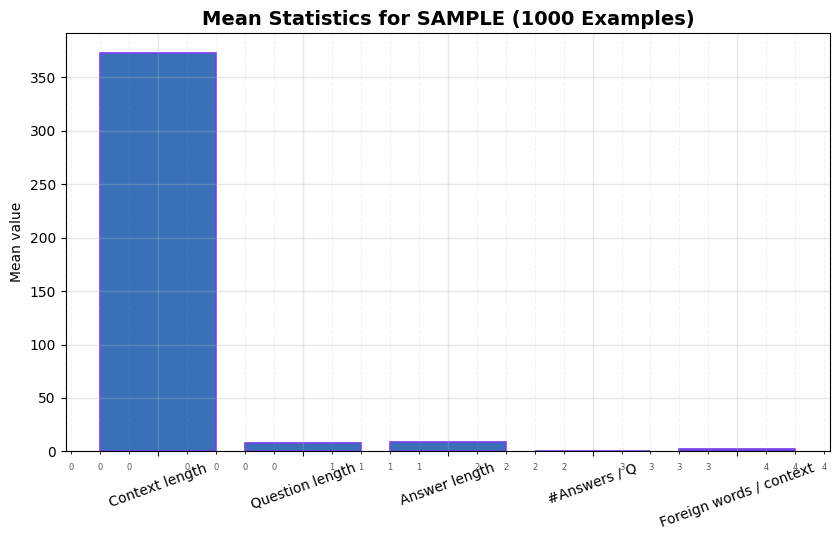

Saved → arabicaqa_rag_results/ragas_full\figures\mean_statistics_sample.png
Saved → arabicaqa_rag_results/ragas_full\figures\mean_statistics_sample.pdf


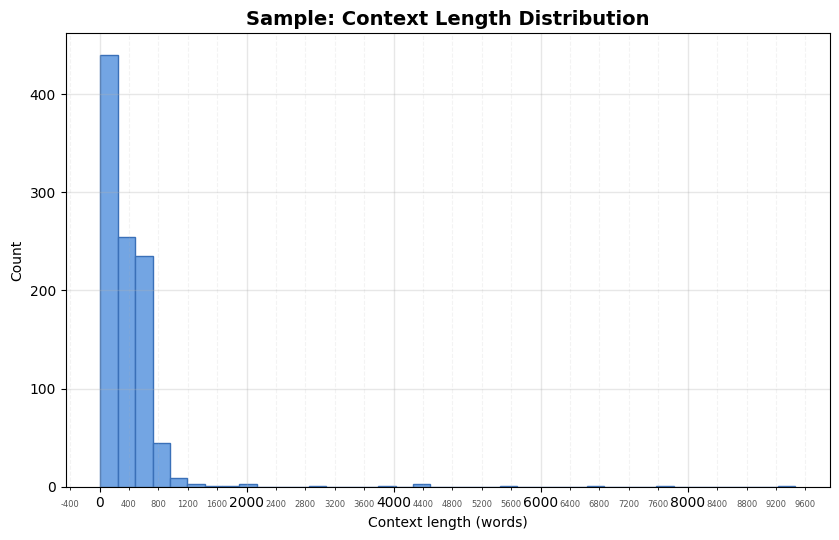

Saved → arabicaqa_rag_results/ragas_full\figures\hist_context_length.png
Saved → arabicaqa_rag_results/ragas_full\figures\hist_context_length.pdf


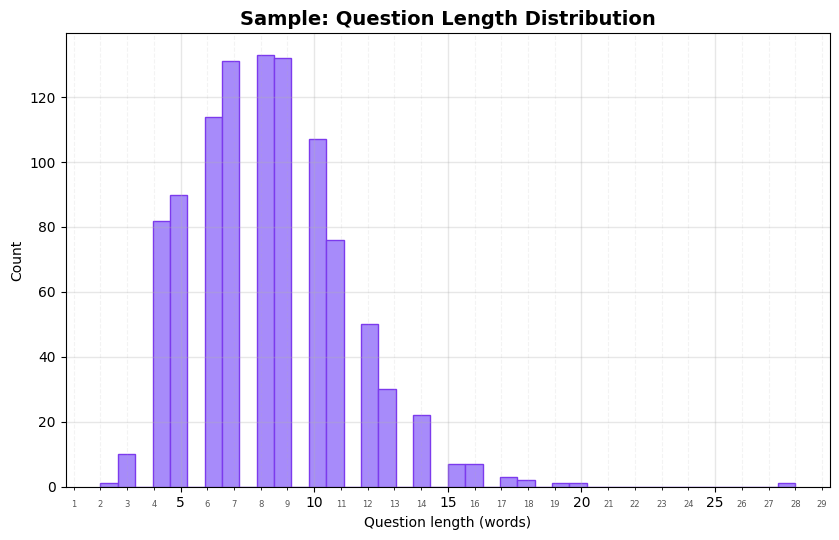

Saved → arabicaqa_rag_results/ragas_full\figures\hist_question_length.png
Saved → arabicaqa_rag_results/ragas_full\figures\hist_question_length.pdf


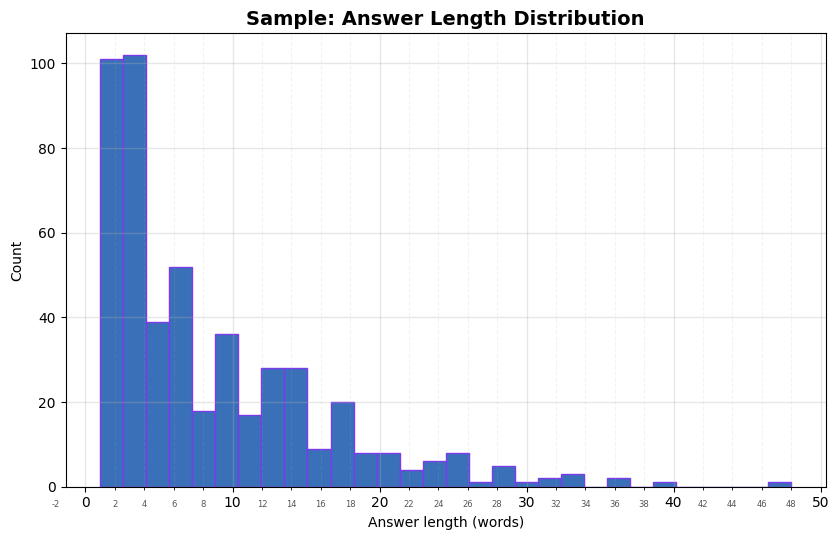

Saved → arabicaqa_rag_results/ragas_full\figures\hist_answer_length.png
Saved → arabicaqa_rag_results/ragas_full\figures\hist_answer_length.pdf


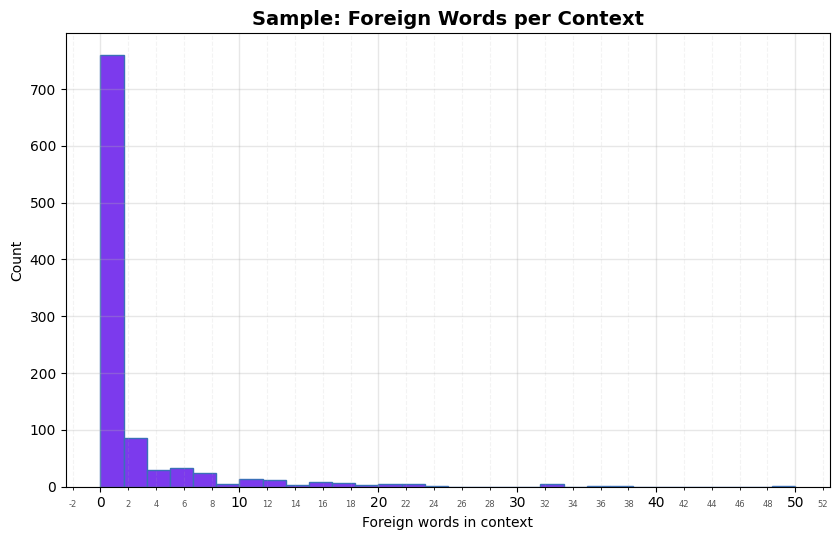

Saved → arabicaqa_rag_results/ragas_full\figures\hist_foreign_words.png
Saved → arabicaqa_rag_results/ragas_full\figures\hist_foreign_words.pdf


In [ ]:
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# ======================
# PATHS
# ======================
OUTPUT_DIR = "arabicaqa_rag_results/ragas_full"
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# ======================
# THEME
# ======================
plt.style.use("default")

PRIMARY   = "#3A70B8"   # Blue
SECONDARY = "#73A5E3"   # Light Blue
ACCENT1   = "#A78BFA"   # Light Purple
ACCENT2   = "#7C3AED"   # Purple


def apply_style_with_minor_ticks(ax):
    """Apply theme + grid + minor ticks with small labels"""
    ax.grid(which="major", alpha=0.3, linewidth=1)
    ax.grid(which="minor", alpha=0.15, linestyle="--")

    ax.xaxis.set_minor_locator(AutoMinorLocator(5))

    minor_ticks = ax.xaxis.get_minorticklocs()
    for tick in minor_ticks:
        ax.text(
            tick,
            -0.045,
            f"{int(tick)}",
            transform=ax.get_xaxis_transform(),
            fontsize=6,
            color="#555555",
            ha="center"
        )

    plt.tight_layout()


# =====================================================
# 1) BAR CHART — MEAN STATISTICS
# =====================================================
labels = [
    "Context length",
    "Question length",
    "Answer length",
    "#Answers / Q",
    "Foreign words / context",
]

values = [
    mean_context_len_s,
    mean_question_len_s,
    mean_answer_len_s,
    mean_n_answers_s,
    mean_foreign_s,
]

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.bar(labels, values, color=PRIMARY, edgecolor=ACCENT2, linewidth=1.2)
ax.set_ylabel("Mean value")
ax.set_title("Mean Statistics for SAMPLE (1000 Examples)", fontsize=14, weight="bold")
ax.tick_params(axis="x", rotation=20)

apply_style_with_minor_ticks(ax)

png = os.path.join(FIG_DIR, "mean_statistics_sample.png")
pdf = os.path.join(FIG_DIR, "mean_statistics_sample.pdf")
plt.savefig(png, dpi=300, bbox_inches="tight")
plt.savefig(pdf, bbox_inches="tight")
plt.show()

print("Saved →", png)
print("Saved →", pdf)


# =====================================================
# 2) HISTOGRAM — CONTEXT LENGTH
# =====================================================
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.hist(df_sample_loaded["context_word_len"], bins=40,
        color=SECONDARY, edgecolor=PRIMARY)

ax.set_xlabel("Context length (words)")
ax.set_ylabel("Count")
ax.set_title("Sample: Context Length Distribution", fontsize=14, weight="bold")

apply_style_with_minor_ticks(ax)

png = os.path.join(FIG_DIR, "hist_context_length.png")
pdf = os.path.join(FIG_DIR, "hist_context_length.pdf")
plt.savefig(png, dpi=300, bbox_inches="tight")
plt.savefig(pdf, bbox_inches="tight")
plt.show()

print("Saved →", png)
print("Saved →", pdf)


# =====================================================
# 3) HISTOGRAM — QUESTION LENGTH
# =====================================================
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.hist(df_sample_loaded["question_word_len"], bins=40,
        color=ACCENT1, edgecolor=ACCENT2)

ax.set_xlabel("Question length (words)")
ax.set_ylabel("Count")
ax.set_title("Sample: Question Length Distribution", fontsize=14, weight="bold")

apply_style_with_minor_ticks(ax)

png = os.path.join(FIG_DIR, "hist_question_length.png")
pdf = os.path.join(FIG_DIR, "hist_question_length.pdf")
plt.savefig(png, dpi=300, bbox_inches="tight")
plt.savefig(pdf, bbox_inches="tight")
plt.show()

print("Saved →", png)
print("Saved →", pdf)


# =====================================================
# 4) HISTOGRAM — ANSWER LENGTH
# =====================================================
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.hist(all_sample_answer_lengths, bins=30,
        color=PRIMARY, edgecolor=ACCENT2)

ax.set_xlabel("Answer length (words)")
ax.set_ylabel("Count")
ax.set_title("Sample: Answer Length Distribution", fontsize=14, weight="bold")

apply_style_with_minor_ticks(ax)

png = os.path.join(FIG_DIR, "hist_answer_length.png")
pdf = os.path.join(FIG_DIR, "hist_answer_length.pdf")
plt.savefig(png, dpi=300, bbox_inches="tight")
plt.savefig(pdf, bbox_inches="tight")
plt.show()

print("Saved →", png)
print("Saved →", pdf)


# =====================================================
# 5) HISTOGRAM — FOREIGN WORDS PER CONTEXT
# =====================================================
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.hist(df_sample_loaded["foreign_words"], bins=30,
        color=ACCENT2, edgecolor=PRIMARY)

ax.set_xlabel("Foreign words in context")
ax.set_ylabel("Count")
ax.set_title("Sample: Foreign Words per Context", fontsize=14, weight="bold")

apply_style_with_minor_ticks(ax)

png = os.path.join(FIG_DIR, "hist_foreign_words.png")
pdf = os.path.join(FIG_DIR, "hist_foreign_words.pdf")
plt.savefig(png, dpi=300, bbox_inches="tight")
plt.savefig(pdf, bbox_inches="tight")
plt.show()

print("Saved →", png)
print("Saved →", pdf)


In [ ]:
import pandas as pd
import json

# ========== Load sample ==========
sample_path = "arabicaqa_rag_results/dataset/df_sample_1000.csv"
df_sample_loaded = pd.read_csv(sample_path)

# ========== Fix list columns after loading ==========
list_columns = ["answers"]

for col in list_columns:
    df_sample_loaded[col] = df_sample_loaded[col].apply(
        lambda x: json.loads(x) if isinstance(x, str) and x.strip().startswith("[") else []
    )

print("✨ Loaded sample shape:", df_sample_loaded.shape)
df_sample_loaded.head()


✨ Loaded sample shape: (1000, 7)


,split,document_id,question_id,question,context,answers,is_impossible
0,train,1732461,1193607,متي تم بناء الموقع الأول لشركة توب غولف؟,توب غولف هي شركة ترفيهية رياضية عالمية مقرها ف...,[عام 2000],False
1,test,1583712,1160774,كم عدد الحفريات التي تم اكتشافها لببر نغاندونغ؟,ببر نغاندونغ هو نويع منقرض من أنواع الببور الح...,[سبع حفريات],False
2,train,1718678,1164879,ما هو مركز اللاعب ميو تساكتاش؟,ميو تساكتاش (8 مايو 1992 في سبليت في كرواتيا -...,[كصانع ألعاب],False
3,test,1582958,1068610,ما هي بعض المنتجات التي يمكن صنعها من القماش ا...,القماش الهَسِّيّ هو قماش منسوج يصنع عادة من أل...,[لصنع الحبال والشبكات والمنتجات المماثلة],False
4,test,1720179,1175188,ما هو مركز اللاعب رادو سابو؟,رادو سابو هو لاعب كرة قدم روماني في مركز الوسط...,[الوسط],False


In [ ]:
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline
import pandas as pd
from tqdm import tqdm
from collections import Counter
import os

ner_results_path = "arabicaqa_rag_results/dataset/sample_ner_counts.csv"

os.makedirs(os.path.dirname(ner_results_path), exist_ok=True)

model_id = "CAMeL-Lab/bert-base-arabic-camelbert-msa-ner"

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForTokenClassification.from_pretrained(model_id)

ner = pipeline(
    "ner",
    model=model,
    tokenizer=tokenizer,
    aggregation_strategy="simple"
)

def get_entity_counts(texts, max_tokens=512):
    entity_counter = Counter()
    for t in tqdm(texts):
        if not isinstance(t, str) or not t.strip():
            continue

        enc = tokenizer(
            t,
            truncation=True,
            max_length=max_tokens,
            return_tensors=None
        )
       
        input_ids = enc["input_ids"]
       
        if isinstance(input_ids[0], int):
            truncated_text = tokenizer.decode(input_ids, skip_special_tokens=True)
        else:
            truncated_text = tokenizer.decode(input_ids[0], skip_special_tokens=True)

        ents = ner(truncated_text)
        for e in ents:
            entity_counter[e["entity_group"]] += 1

    return entity_counter


# ==============================
# SAMPLE entities (ACTIVE)
# ==============================
sample_contexts = df_sample_loaded["context"].dropna().tolist()

sample_entity_counts = get_entity_counts(sample_contexts)

print("\n=== SAMPLE NER STATISTICS ===")
for k, v in sample_entity_counts.items():
    print(f"{k}: {v}")

df_ner = pd.DataFrame({
    "entity_type": list(sample_entity_counts.keys()),
    "sample": list(sample_entity_counts.values()),
})


df_ner.to_csv(ner_results_path, index=False, encoding="utf-8-sig")

print(f"Saved NER results to: {ner_results_path}")
print(df_ner.head())


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6535.84it/s]
[transformers] BertForTokenClassification LOAD REPORT from: CAMeL-Lab/bert-base-arabic-camelbert-msa-ner
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
100%|██████████| 1000/1000 [12:44<00:00,  1.31it/s]


=== SAMPLE NER STATISTICS ===
ORG: 2058
LOC: 11581
PERS: 6686
MISC: 3737
Saved NER results to: arabicaqa_rag_results/dataset/sample_ner_counts.csv
  entity_type  sample
0         ORG    2058
1         LOC   11581
2        PERS    6686
3        MISC    3737


In [ ]:
import pandas as pd

ner_results_path = "arabicaqa_rag_results/dataset/sample_ner_counts.csv"

df_sample_ner_loaded = pd.read_csv(ner_results_path)

print("✨ Loaded NER results:")
print(df_sample_ner_loaded.head())


✨ Loaded NER results:
  entity_type  sample
0         ORG    2058
1         LOC   11581
2        PERS    6686
3        MISC    3737


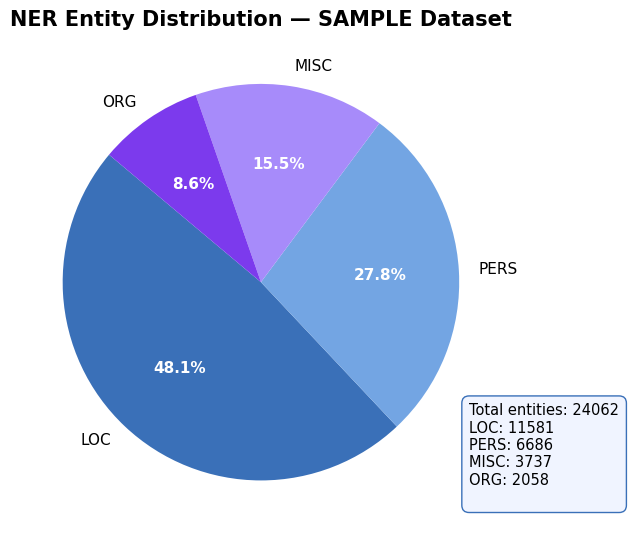

Saved → arabicaqa_rag_results/ragas_full\figures\sample_ner_entity_distribution_pie.png
Saved → arabicaqa_rag_results/ragas_full\figures\sample_ner_entity_distribution_pie.pdf


In [ ]:
import os
import matplotlib.pyplot as plt

# ====== Theme colors ======
PRIMARY   = "#3A70B8"   # Blue
SECONDARY = "#73A5E3"   # Light Blue
ACCENT1   = "#A78BFA"   # Light Purple
ACCENT2   = "#7C3AED"   # Purple

colors = [PRIMARY, SECONDARY, ACCENT1, ACCENT2, "#4FB6A0", "#F2A93B", "#D96459"]

# ======================
# PATHS
# ======================
OUTPUT_DIR = "arabicaqa_rag_results/ragas_full"
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# ======================
# PREPARE DATA
# ======================
df_plot = df_sample_ner_loaded.sort_values("sample", ascending=False)

labels = df_plot["entity_type"].astype(str).tolist()
sizes  = df_plot["sample"].astype(float).tolist()

total_entities = int(sum(sizes))

# ======================
# PIE CHART
# ======================
fig, ax = plt.subplots(figsize=(6.5, 5.5))

patches, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    colors=colors[:len(labels)],
    startangle=140,
    textprops={"fontsize": 11}
)

# improve label style on wedges
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontsize(11)
    autotext.set_weight("bold")

ax.set_title("NER Entity Distribution — SAMPLE Dataset", fontsize=15, weight="bold")

# ========= Inset Box ==========
box_text = f"Total entities: {total_entities}\n"
for ent, count in zip(labels, sizes):
    box_text += f"{ent}: {int(count)}\n"

props = dict(boxstyle="round,pad=0.5", facecolor="#F0F4FF", edgecolor=PRIMARY)

ax.text(
    0.92, 0.05,                 # box position inside axes
    box_text,
    transform=ax.transAxes,
    fontsize=10.5,
    verticalalignment="bottom",
    horizontalalignment="left",
    bbox=props
)

plt.tight_layout()

# ======================
# SAVE
# ======================
png_path = os.path.join(FIG_DIR, "sample_ner_entity_distribution_pie.png")
pdf_path = os.path.join(FIG_DIR, "sample_ner_entity_distribution_pie.pdf")

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()

print(f"Saved → {png_path}")
print(f"Saved → {pdf_path}")
